<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/QCCM_601_Practical_Quantum_Chemical_Simulation_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QCCM-601: Practical Quantum Chemical Simulation on Advanced Global Hardware

**Special Graduate Enrichment Module**  
**4-Week Live-Streamed Guest Lecture Series**

**Instructor:** Joseph Volkan Ozcan, PhD Candidate & Quantum Computing Ambassador  
**Contact:** [LinkedIn](https://www.linkedin.com/in/sapyoda/) | Quantum Task Force

---

### Course Overview
This notebook is a complete, end-to-end, fully executable educational implementation of the QCCM-601 syllabus.  
It is enriched with **diagrams, circuit drawings, molecular illustrations, heatmaps, workflow charts and comparative plots** so that every major concept is visualized.

**Topics covered**
- Molecular Hamiltonians & active-space methods
- VQE + qEOM for ground and excited states
- Quantum Machine Learning for materials
- Quantum dynamics, error mitigation, and IP strategy
- Clear pathways to IBM Condor (1,121 qubits), Origin Wukong, and D-Wave hardware

**How to use in Google Colab**
1. Runtime → Change runtime type → Prefer GPU (optional).
2. Run the **Installation** cell first.
3. Execute cells sequentially. Plots appear inline.
4. Real hardware access requires separate cloud accounts; simulators are used by default.


## 0. Environment Installation & Verification

Run this cell once. It installs the full stack and configures a consistent plotting style used throughout the notebook.


In [ ]:
# =============================================================================
# QCCM-601 - Full Software Stack + Plotting Style
# =============================================================================
import sys
print(f"Python: {sys.version.split()[0]}")

%pip install -q --upgrade pip
%pip install -q "qiskit>=1.0" qiskit-aer qiskit-algorithms \
               "qiskit-nature[pyscf]>=0.7" qiskit-machine-learning \
               pyscf pennylane pennylane-qiskit \
               matplotlib seaborn pandas scikit-learn tqdm ipywidgets networkx pylatexenc

print("\nInstallation complete. Verifying imports and setting plot style...")

import qiskit, qiskit_nature, qiskit_algorithms, pyscf, pennylane as qml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Rectangle, Ellipse
import seaborn as sns

# Consistent teaching style
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
})
sns.set_palette("colorblind")

print(f"Qiskit              : {qiskit.__version__}")
print(f"Qiskit Nature       : {qiskit_nature.__version__}")
print(f"PySCF               : {pyscf.__version__}")
print(f"PennyLane           : {qml.__version__}")
print("All packages ready. Plotting style configured.")

# Safe circuit drawer (falls back to text if pylatexenc/mpl unavailable)
def safe_circuit_draw(circuit, title=None, fold=40, **kwargs):
    try:
        fig = circuit.draw(output="mpl", style="iqp", fold=fold, **kwargs)
        if title:
            import matplotlib.pyplot as plt
            plt.suptitle(title, fontsize=12, fontweight="bold", y=1.01)
            plt.tight_layout()
            plt.show()
        return fig
    except Exception as e:
        print(f"[Circuit draw fallback - {type(e).__name__}] Using text drawer instead.")
        print(circuit.draw(output="text", fold=fold))
        return None


Python: 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.3 MB/s eta 0:00:00

Installation complete. Verifying imports and setting plot style...
Qiskit              : 2.3.0
Qiskit Nature       : 0.8.0
PySCF               : 2.14.0
PennyLane           : 0.45.1
All packages ready. Plotting style configured.


---
# Week 1: Molecular Hamiltonians & Active Space Mapping

### Theoretical Content
- Second Quantization and Fermionic Operators
- Molecular Hamiltonian formulation
- Jordan-Wigner, Parity, and Bravyi-Kitaev mappings
- Classical pre-processing limits and active-space reduction
- Mapping reduced problems onto physical qubit topologies (IBM Condor heavy-hex, Origin Wukong)

### Hands-on Goals
1. Build electronic structure problems with PySCFDriver
2. Apply `ActiveSpaceTransformer`
3. Compare qubit counts and Pauli-term counts across mappers
4. Visualize molecules, active spaces, and hardware topologies


### 1.1 Building the Electronic Structure Problem & Molecular Visualization


FULL LiH PROBLEM (STO-3G)
Particles (alpha, beta) : (2, 2)
Spatial orbitals        : 6
Qubits (Jordan-Wigner)  : 12


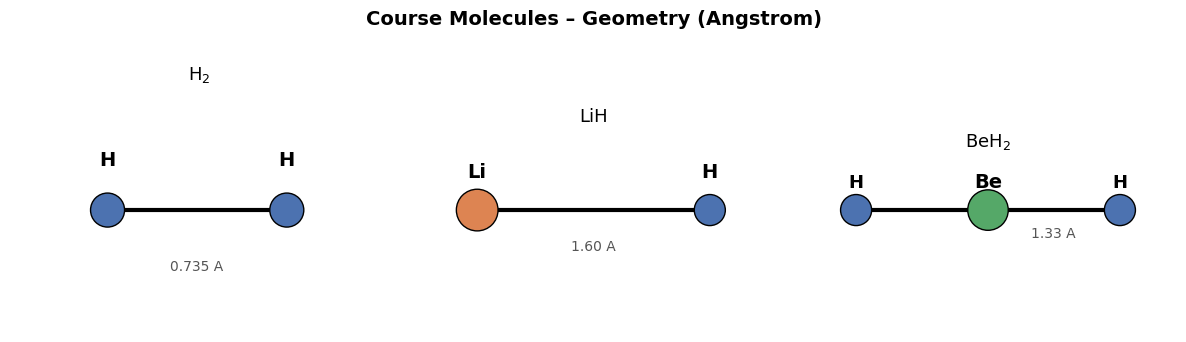

In [ ]:
# Week 1 - Cell 1: Imports, molecules, and geometry visualization
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer, FreezeCoreTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper, BravyiKitaevMapper
from qiskit_nature.units import DistanceUnit
from qiskit.quantum_info import SparsePauliOp
import numpy as np

MOLECULES = {
    "H2":  "H 0.0 0.0 0.0; H 0.0 0.0 0.735",
    "LiH": "Li 0.0 0.0 0.0; H 0.0 0.0 1.6",
    "BeH2": "Be 0.0 0.0 0.0; H 0.0 0.0 1.326; H 0.0 0.0 -1.326"
}

def build_problem(atom_str, basis="sto-3g", charge=0, spin=0):
    # Create an ElectronicStructureProblem via PySCF
    driver = PySCFDriver(atom=atom_str, basis=basis, charge=charge,
                         spin=spin, unit=DistanceUnit.ANGSTROM)
    return driver.run()

problem_full = build_problem(MOLECULES["LiH"])

print("=" * 60)
print("FULL LiH PROBLEM (STO-3G)")
print("=" * 60)
print(f"Particles (alpha, beta) : {problem_full.num_particles}")
print(f"Spatial orbitals        : {problem_full.num_spatial_orbitals}")
print(f"Qubits (Jordan-Wigner)  : {2 * problem_full.num_spatial_orbitals}")

# ----- Molecular geometry diagram -----
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
fig.suptitle("Course Molecules – Geometry (Angstrom)", fontsize=14, fontweight="bold")

# H2
ax = axes[0]
ax.scatter([0, 0.735], [0, 0], s=600, c=["#4C72B0", "#4C72B0"], zorder=5, edgecolors="k")
ax.plot([0, 0.735], [0, 0], "k-", lw=3, zorder=1)
ax.text(0, 0.18, "H", ha="center", fontsize=14, fontweight="bold")
ax.text(0.735, 0.18, "H", ha="center", fontsize=14, fontweight="bold")
ax.text(0.367, -0.25, "0.735 A", ha="center", fontsize=10, color="#555")
ax.set_xlim(-0.4, 1.15); ax.set_ylim(-0.5, 0.5)
ax.set_aspect("equal"); ax.axis("off"); ax.set_title("H$_2$")

# LiH
ax = axes[1]
ax.scatter([0, 1.6], [0, 0], s=[900, 500], c=["#DD8452", "#4C72B0"], zorder=5, edgecolors="k")
ax.plot([0, 1.6], [0, 0], "k-", lw=3, zorder=1)
ax.text(0, 0.22, "Li", ha="center", fontsize=14, fontweight="bold")
ax.text(1.6, 0.22, "H", ha="center", fontsize=14, fontweight="bold")
ax.text(0.8, -0.28, "1.60 A", ha="center", fontsize=10, color="#555")
ax.set_xlim(-0.5, 2.1); ax.set_ylim(-0.55, 0.55)
ax.set_aspect("equal"); ax.axis("off"); ax.set_title("LiH")

# BeH2
ax = axes[2]
ax.scatter([0, 1.326, -1.326], [0, 0, 0], s=[850, 500, 500],
           c=["#55A868", "#4C72B0", "#4C72B0"], zorder=5, edgecolors="k")
ax.plot([-1.326, 1.326], [0, 0], "k-", lw=3, zorder=1)
ax.text(0, 0.22, "Be", ha="center", fontsize=14, fontweight="bold")
ax.text(1.326, 0.22, "H", ha="center", fontsize=13, fontweight="bold")
ax.text(-1.326, 0.22, "H", ha="center", fontsize=13, fontweight="bold")
ax.text(0.66, -0.28, "1.33 A", ha="center", fontsize=10, color="#555")
ax.set_xlim(-1.9, 1.9); ax.set_ylim(-0.55, 0.55)
ax.set_aspect("equal"); ax.axis("off"); ax.set_title("BeH$_2$")

plt.tight_layout()
plt.show()


### 1.2 Active-Space Reduction – Concept Diagram + Code


ACTIVE-SPACE REDUCED PROBLEM (2e, 2o)
Particles (alpha, beta)    : (1, 1)
Spatial orbitals           : 2
Qubits under Jordan-Wigner : 4


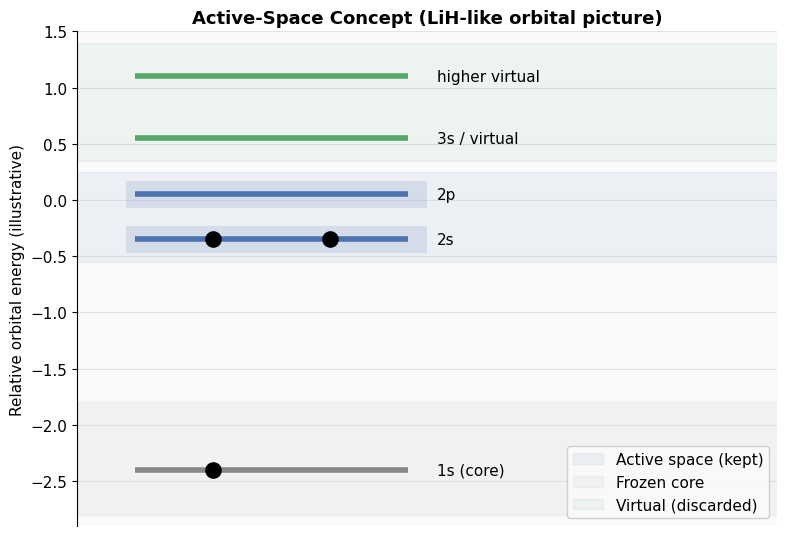


Interpretation: only the chemically relevant frontier orbitals enter the quantum algorithm.
This is the main reason NISQ quantum chemistry is feasible for small molecules.


In [ ]:
# Week 1 - Cell 2: Active space reduction + orbital energy diagram

as_transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)
problem_reduced = as_transformer.transform(problem_full)

print("=" * 60)
print("ACTIVE-SPACE REDUCED PROBLEM (2e, 2o)")
print("=" * 60)
print(f"Particles (alpha, beta)    : {problem_reduced.num_particles}")
print(f"Spatial orbitals           : {problem_reduced.num_spatial_orbitals}")
print(f"Qubits under Jordan-Wigner : {2 * problem_reduced.num_spatial_orbitals}")

# ----- Conceptual orbital diagram -----
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.set_title("Active-Space Concept (LiH-like orbital picture)", fontweight="bold")

# Approximate orbital energies (illustrative, not exact)
orbitals = [
    ("1s (core)", -2.4, "frozen", "#888888"),
    ("2s", -0.35, "active", "#4C72B0"),
    ("2p", 0.05, "active", "#4C72B0"),
    ("3s / virtual", 0.55, "virtual", "#55A868"),
    ("higher virtual", 1.1, "virtual", "#55A868"),
]

for i, (label, energy, kind, color) in enumerate(orbitals):
    y = energy
    ax.hlines(y, 0.3, 1.7, colors=color, lw=4, zorder=3)
    ax.text(1.85, y, label, va="center", fontsize=11)
    if kind == "active":
        ax.add_patch(Rectangle((0.25, y-0.12), 1.55, 0.24,
                               facecolor="#4C72B0", alpha=0.15, zorder=1))

# Electrons
ax.scatter([0.7, 1.3], [-0.35, -0.35], s=120, c="k", zorder=5, marker="o")
ax.scatter([0.7], [-2.4], s=120, c="k", zorder=5, marker="o")  # core pair simplified

ax.axhspan(-0.55, 0.25, alpha=0.08, color="#4C72B0", label="Active space (kept)")
ax.axhspan(-2.8, -1.8, alpha=0.08, color="#888888", label="Frozen core")
ax.axhspan(0.35, 1.4, alpha=0.08, color="#55A868", label="Virtual (discarded)")

ax.set_xlim(0, 3.6)
ax.set_ylim(-2.9, 1.5)
ax.set_ylabel("Relative orbital energy (illustrative)")
ax.set_xticks([])
ax.legend(loc="lower right", framealpha=0.95)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.show()

print("\nInterpretation: only the chemically relevant frontier orbitals enter the quantum algorithm.")
print("This is the main reason NISQ quantum chemistry is feasible for small molecules.")


### 1.3 Fermion-to-Qubit Mappings – Comparison Chart


Jordan-Wigner       qubits= 4  Pauli terms= 27
Parity              qubits= 2  Pauli terms=  9
Bravyi-Kitaev       qubits= 4  Pauli terms= 27


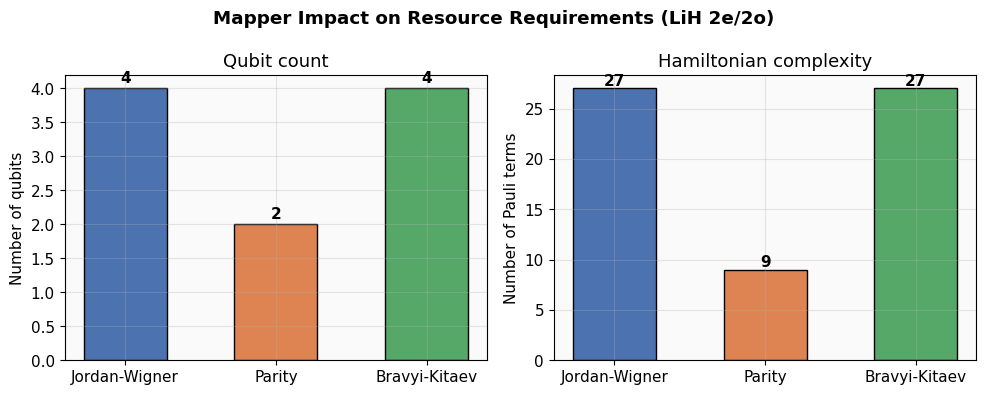


Parity mapping often wins for small molecules because of the 2-qubit reduction.


In [ ]:
# Week 1 - Cell 3: Mapper comparison + bar chart

mappers = {
    "Jordan-Wigner": JordanWignerMapper(),
    "Parity":        ParityMapper(num_particles=problem_reduced.num_particles),
    "Bravyi-Kitaev": BravyiKitaevMapper()
}

names, n_qubits, n_terms = [], [], []
qubit_ops = {}
for name, mapper in mappers.items():
    op = mapper.map(problem_reduced.hamiltonian.second_q_op())
    qubit_ops[name] = op
    names.append(name)
    n_qubits.append(op.num_qubits)
    n_terms.append(len(op))
    print(f"{name:<18}  qubits={op.num_qubits:2d}  Pauli terms={len(op):3d}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Mapper Impact on Resource Requirements (LiH 2e/2o)", fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868"]
axes[0].bar(names, n_qubits, color=colors, edgecolor="k", width=0.55)
axes[0].set_ylabel("Number of qubits")
axes[0].set_title("Qubit count")
for i, v in enumerate(n_qubits):
    axes[0].text(i, v + 0.08, str(v), ha="center", fontweight="bold")

axes[1].bar(names, n_terms, color=colors, edgecolor="k", width=0.55)
axes[1].set_ylabel("Number of Pauli terms")
axes[1].set_title("Hamiltonian complexity")
for i, v in enumerate(n_terms):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nParity mapping often wins for small molecules because of the 2-qubit reduction.")


### 1.4 Hardware Topology Awareness – Heavy-Hex Lattice Diagram


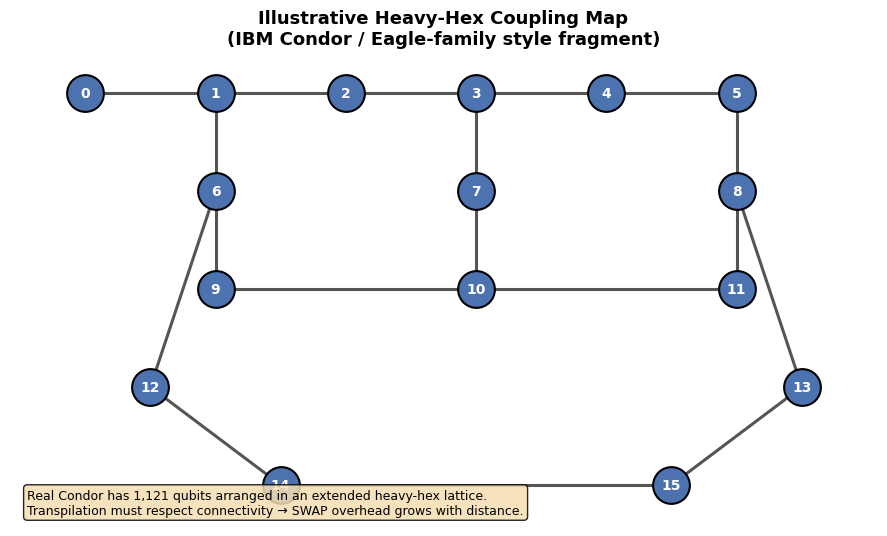

In production you query the real backend coupling map and transpile with optimization_level=3.


In [ ]:
# Week 1 - Cell 4: Heavy-hex topology visualization (educational)

from qiskit.transpiler import CouplingMap
import networkx as nx

# Illustrative heavy-hex fragment inspired by IBM architectures
# (Condor is a much larger instance of the same lattice family)
edges = [
    (0,1), (1,2), (2,3), (3,4), (4,5),
    (1,6), (3,7), (5,8),
    (6,9), (7,10), (8,11),
    (9,10), (10,11),
    (6,12), (8,13),
    (12,14), (13,15), (14,15)
]
cm = CouplingMap(edges)
G = nx.Graph()
G.add_edges_from(edges)

# Layout that roughly resembles a heavy-hex fragment
pos = {
    0:(0,2), 1:(1,2), 2:(2,2), 3:(3,2), 4:(4,2), 5:(5,2),
    6:(1,1), 7:(3,1), 8:(5,1),
    9:(1,0), 10:(3,0), 11:(5,0),
    12:(0.5,-1), 13:(5.5,-1),
    14:(1.5,-2), 15:(4.5,-2)
}

fig, ax = plt.subplots(figsize=(9, 5.5))
nx.draw_networkx_nodes(G, pos, node_color="#4C72B0", node_size=700,
                       edgecolors="k", linewidths=1.5, ax=ax)
nx.draw_networkx_edges(G, pos, width=2.2, edge_color="#555", ax=ax)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold", font_size=10, ax=ax)
ax.set_title("Illustrative Heavy-Hex Coupling Map\n(IBM Condor / Eagle-family style fragment)", fontweight="bold")
ax.axis("off")
ax.text(0.02, 0.02,
        "Real Condor has 1,121 qubits arranged in an extended heavy-hex lattice.\n"
        "Transpilation must respect connectivity → SWAP overhead grows with distance.",
        transform=ax.transAxes, fontsize=9, va="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.85))
plt.tight_layout()
plt.show()

print("In production you query the real backend coupling map and transpile with optimization_level=3.")


### Week 1 – Summary & Checkpoint
- You can generate molecular Hamiltonians, reduce them with active-space techniques, and map them to qubits.
- Qubit count and Pauli-term count are the primary cost drivers for VQE on superconducting hardware.
- Heavy-hex connectivity forces careful transpilation on Condor-class devices.


---
# Week 2: Ground & Excited States via Variational Solvers

### Theoretical Content
- Variational Quantum Eigensolver (VQE) architecture
- Unitary Coupled Cluster (UCCSD) Ansatz
- Optimization landscapes and convergence
- Quantum Equation of Motion (qEOM) for excited states

### Hands-on Goals
1. Compute ground-state energies of H₂ and LiH with UCCSD-VQE
2. Visualize the VQE workflow and the ansatz circuit
3. Compute excited states with qEOM
4. Understand the path to large hardware


### 2.0 VQE Workflow Diagram


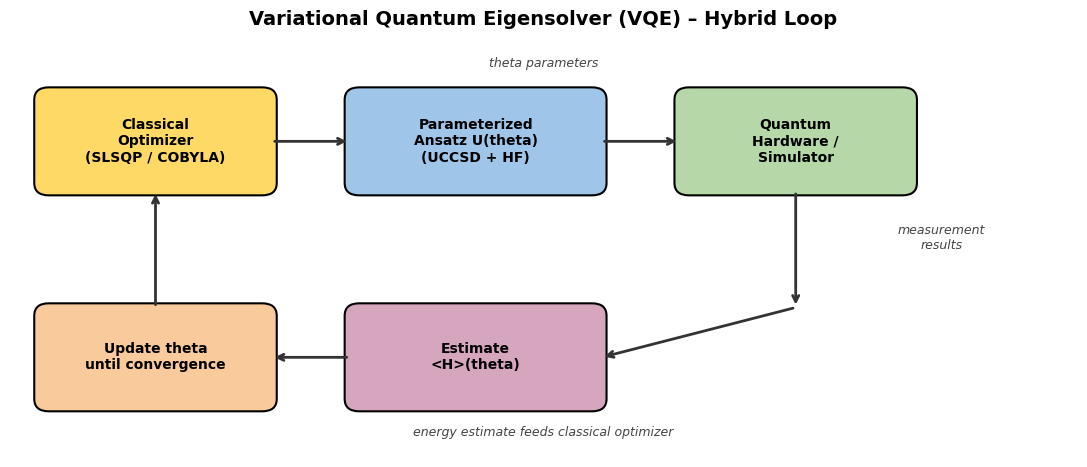

In [ ]:
# Week 2 - Visual: VQE hybrid loop diagram

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)
ax.axis("off")
ax.set_title("Variational Quantum Eigensolver (VQE) – Hybrid Loop", fontsize=14, fontweight="bold", pad=12)

def box(x, y, w, h, text, color, ax):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05,rounding_size=0.15",
                       facecolor=color, edgecolor="k", linewidth=1.5, zorder=2)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10,
            fontweight="bold", wrap=True, zorder=3)

# Boxes
box(0.3, 3.2, 2.4, 1.2, "Classical\nOptimizer\n(SLSQP / COBYLA)", "#FFD966", ax)
box(3.5, 3.2, 2.6, 1.2, "Parameterized\nAnsatz U(theta)\n(UCCSD + HF)", "#9FC5E8", ax)
box(6.9, 3.2, 2.4, 1.2, "Quantum\nHardware /\nSimulator", "#B6D7A8", ax)
box(3.5, 0.6, 2.6, 1.2, "Estimate\n<H>(theta)", "#D5A6BD", ax)
box(0.3, 0.6, 2.4, 1.2, "Update theta\nuntil convergence", "#F9CB9C", ax)

# Arrows
def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="#333", lw=2))

arrow(2.7, 3.8, 3.5, 3.8)   # optimizer -> ansatz
arrow(6.1, 3.8, 6.9, 3.8)   # ansatz -> QPU
arrow(8.1, 3.2, 8.1, 1.8)   # QPU down
arrow(8.1, 1.8, 6.1, 1.2)   # to estimate
arrow(3.5, 1.2, 2.7, 1.2)   # estimate -> update
arrow(1.5, 1.8, 1.5, 3.2)   # update -> optimizer

ax.text(5.5, 4.7, "theta parameters", ha="center", fontsize=9, style="italic", color="#444")
ax.text(9.6, 2.5, "measurement\nresults", ha="center", fontsize=9, style="italic", color="#444")
ax.text(5.5, 0.25, "energy estimate feeds classical optimizer", ha="center", fontsize=9, style="italic", color="#444")

plt.tight_layout()
plt.show()


### 2.1 Complete VQE Pipeline for H₂ + Circuit Drawing


In [ ]:
# Week 2 - Cell 1: Full VQE for H2 + ansatz visualization

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import StatevectorEstimator

problem_h2 = build_problem(MOLECULES["H2"])
print("H2 problem: particles =", problem_h2.num_particles,
      "| spatial orbitals =", problem_h2.num_spatial_orbitals)

mapper = ParityMapper(num_particles=problem_h2.num_particles)
hf_state = HartreeFock(problem_h2.num_spatial_orbitals, problem_h2.num_particles, mapper)
ansatz = UCCSD(problem_h2.num_spatial_orbitals, problem_h2.num_particles, mapper,
               initial_state=hf_state)

print(f"Ansatz qubits: {ansatz.num_qubits} | parameters: {ansatz.num_parameters}")

# Draw the ansatz circuit (decomposed enough to be readable)
safe_circuit_draw(ansatz.decompose(), title="UCCSD Ansatz for H2 (Parity mapping)", fold=40)

# Run VQE
estimator = StatevectorEstimator()
vqe = VQE(estimator, ansatz, SLSQP(maxiter=250))
vqe.initial_point = np.zeros(ansatz.num_parameters)
solver = GroundStateEigensolver(mapper, vqe)
result_h2 = solver.solve(problem_h2)

print("=" * 60)
print("H2 GROUND-STATE VQE RESULT")
print("=" * 60)
print(f"Total energy     : {result_h2.total_energies[0]:.8f} Ha")
print(f"Electronic energy: {result_h2.electronic_energies[0]:.8f} Ha")
print("Reference (FCI/STO-3G) approx -1.137 Ha electronic")


H2 problem: particles = (1, 1) | spatial orbitals = 2
Ansatz qubits: 2 | parameters: 3


<Figure size 900x500 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


H2 GROUND-STATE VQE RESULT
Total energy     : -1.13730604 Ha
Electronic energy: -1.85727503 Ha
Reference (FCI/STO-3G) approx -1.137 Ha electronic


### 2.2 Potential Energy Surface (PES) Scan for H₂


Scanning H2 PES (this may take ~20-40 s)...


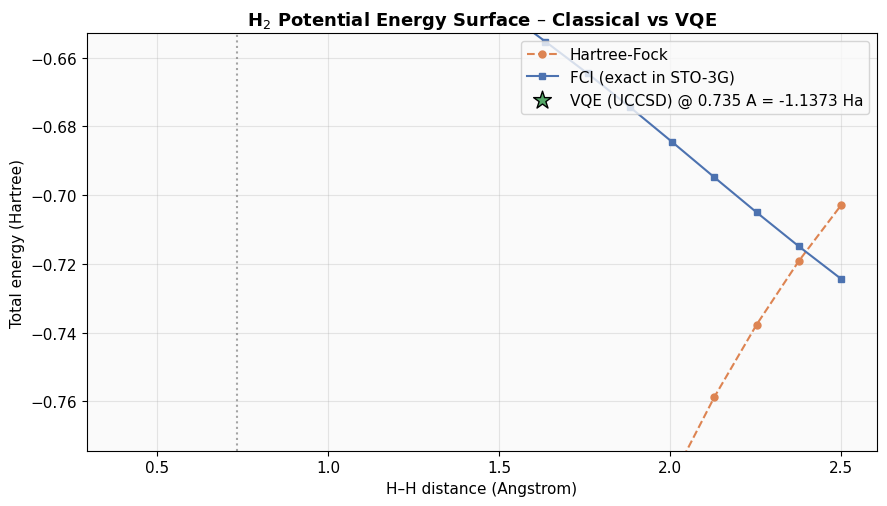

In [ ]:
# Week 2 - Visual: H2 potential energy surface (classical reference + VQE points)

from qiskit_nature.second_q.drivers import PySCFDriver

distances = np.linspace(0.4, 2.5, 18)
energies_hf = []
energies_fci = []

print("Scanning H2 PES (this may take ~20-40 s)...")
for d in distances:
    driver = PySCFDriver(atom=f"H 0 0 0; H 0 0 {d}", basis="sto-3g",
                         unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    # Nuclear repulsion is included in total energy later; we store electronic + nuclear via driver
    # For simplicity we recompute total energy via a quick classical solver path
    from pyscf import gto, scf, fci
    mol = gto.M(atom=f"H 0 0 0; H 0 0 {d}", basis="sto3g", unit="Angstrom", verbose=0)
    mf = scf.RHF(mol).run()
    energies_hf.append(mf.e_tot)
    cisolver = fci.FCI(mol, mf.mo_coeff)
    e_fci, _ = cisolver.kernel()
    energies_fci.append(e_fci + mol.energy_nuc())

# VQE result at equilibrium (from previous cell)
vqe_dist = 0.735
vqe_e = result_h2.total_energies[0]

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(distances, energies_hf, "o--", label="Hartree-Fock", color="#DD8452", markersize=5)
ax.plot(distances, energies_fci, "s-", label="FCI (exact in STO-3G)", color="#4C72B0", markersize=5)
ax.scatter([vqe_dist], [vqe_e], s=180, c="#55A868", marker="*", zorder=5,
           label=f"VQE (UCCSD) @ 0.735 A = {vqe_e:.4f} Ha", edgecolors="k")
ax.axvline(0.735, color="gray", ls=":", alpha=0.7)
ax.set_xlabel("H–H distance (Angstrom)")
ax.set_ylabel("Total energy (Hartree)")
ax.set_title("H$_2$ Potential Energy Surface – Classical vs VQE", fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylim(min(energies_fci)-0.05, max(energies_hf)+0.05)
plt.tight_layout()
plt.show()


### 2.3 VQE for LiH (Active Space) + Energy Comparison Chart


LiH (2e,2o) GROUND-STATE VQE RESULT
Total energy     : -7.86212881 Ha
Electronic energy: -8.85433608 Ha


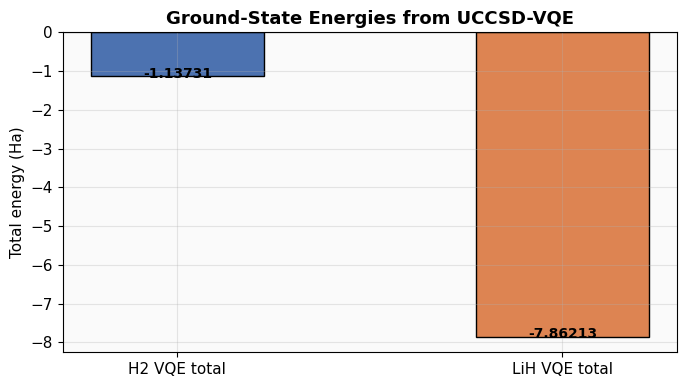

In [ ]:
# Week 2 - Cell 2: LiH active-space VQE + comparison bar

problem_lih_full = build_problem(MOLECULES["LiH"])
as_transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)
problem_lih = as_transformer.transform(problem_lih_full)

mapper_lih = ParityMapper(num_particles=problem_lih.num_particles)
hf_lih = HartreeFock(problem_lih.num_spatial_orbitals, problem_lih.num_particles, mapper_lih)
ansatz_lih = UCCSD(problem_lih.num_spatial_orbitals, problem_lih.num_particles, mapper_lih,
                   initial_state=hf_lih)

vqe_lih = VQE(StatevectorEstimator(), ansatz_lih, SLSQP(maxiter=300))
vqe_lih.initial_point = np.zeros(ansatz_lih.num_parameters)
solver_lih = GroundStateEigensolver(mapper_lih, vqe_lih)
result_lih = solver_lih.solve(problem_lih)

print("=" * 60)
print("LiH (2e,2o) GROUND-STATE VQE RESULT")
print("=" * 60)
print(f"Total energy     : {result_lih.total_energies[0]:.8f} Ha")
print(f"Electronic energy: {result_lih.electronic_energies[0]:.8f} Ha")

# Comparison chart
labels = ["H2 VQE total", "LiH VQE total"]
vals = [result_h2.total_energies[0], result_lih.total_energies[0]]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, vals, color=["#4C72B0", "#DD8452"], edgecolor="k", width=0.45)
ax.set_ylabel("Total energy (Ha)")
ax.set_title("Ground-State Energies from UCCSD-VQE", fontweight="bold")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01 if v > 0 else v - 0.03,
            f"{v:.5f}", ha="center", fontweight="bold", fontsize=10)
ax.axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()


### 2.4 Excited States with qEOM


H2 EXCITED-STATE RESULTS (qEOM)
=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -1.857275030145
  - computed part:      -1.857275030145
~ Nuclear repulsion energy (Hartree): 0.719968994449
> Total ground state energy (Hartree): -1.137306035696
 
=== EXCITED STATE ENERGIES ===
 
  1: 
* Electronic excited state energy (Hartree): -1.244586749357
> Total excited state energy (Hartree): -0.524617754908
  2: 
* Electronic excited state energy (Hartree): -0.882724349759
> Total excited state energy (Hartree): -0.16275535531
  3: 
* Electronic excited state energy (Hartree): -0.224913452353
> Total excited state energy (Hartree): 0.495055542096
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 0.000 S: 0.000 S^2: 0.000 M: 0.000
  1:  # Particles: 0.000 S: 0.000 S^2: 0.000 M: 0.000
  2:  # Particles: 0.000 S: 0.000 S^2: 0.000 M: 0.000
  3:  # Particles: 0.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  0.0  1.3889487

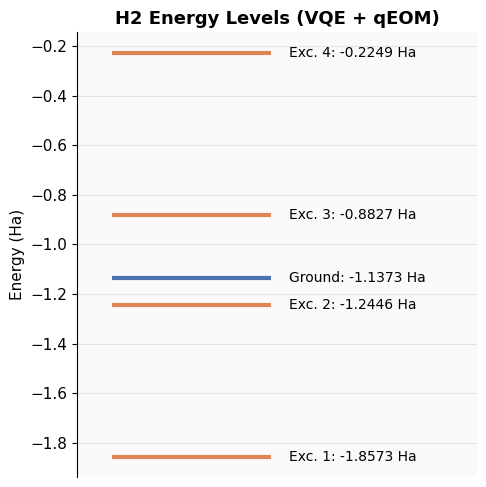

In [ ]:
# Week 2 - Cell 3: qEOM for excited states (H2)

from qiskit_nature.second_q.algorithms import QEOM

qeom = QEOM(solver, estimator, excitations="sd")
excited = qeom.solve(problem_h2)

print("=" * 60)
print("H2 EXCITED-STATE RESULTS (qEOM)")
print("=" * 60)
print(excited)

# Simple energy-level diagram if excitation data is present
try:
    gs = result_h2.total_energies[0]
    # qEOM result structure can vary by version; attempt common attributes
    exc = None
    if hasattr(excited, "computed_energies"):
        exc = np.array(excited.computed_energies).real
    elif hasattr(excited, "excitation_energies"):
        exc = np.array(excited.excitation_energies).real + gs

    if exc is not None and len(exc) > 0:
        levels = np.concatenate(([gs], exc[:4]))
        fig, ax = plt.subplots(figsize=(5, 5))
        for i, e in enumerate(levels):
            ax.hlines(e, 0.3, 1.7, colors="#4C72B0" if i == 0 else "#DD8452", lw=3)
            label = "Ground" if i == 0 else f"Exc. {i}"
            ax.text(1.85, e, f"{label}: {e:.4f} Ha", va="center", fontsize=10)
        ax.set_xlim(0, 3.5)
        ax.set_ylabel("Energy (Ha)")
        ax.set_title("H2 Energy Levels (VQE + qEOM)", fontweight="bold")
        ax.set_xticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Energy-level plot skipped (result structure variation):", type(e).__name__)


### 2.5 Path to Hardware (>1000 qubits)

```python
# Example skeleton for IBM Quantum Runtime (requires token)
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, Session

service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_TOKEN")
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=100)

with Session(backend=backend) as session:
    estimator = EstimatorV2(session=session)
    vqe_hw = VQE(estimator, ansatz, optimizer)
    ...
```

**Practical notes**
- UCCSD depth grows rapidly → adaptive / hardware-efficient ansatze become attractive.
- Always start from the Hartree-Fock state.
- Error mitigation is mandatory beyond ~10–15 qubits on current devices.


---
# Week 3: Quantum Machine Learning (QML) for Advanced Matter

### Theoretical Content
- Data encoding (Angle vs Amplitude)
- Quantum Kernel Methods
- Variational Quantum Classifiers / Quantum Neural Networks
- Application to material phase classification and formation-energy prediction


### 3.1 Quantum Kernel + QSVC – Feature Map & Kernel Heatmap


/tmp/ipykernel_493/4081087737.py:22: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4, reps=2, entanglement="full")


<Figure size 900x500 with 0 Axes>

QSVC test accuracy: 0.7111
              precision    recall  f1-score   support

           0      0.727     0.696     0.711        23
           1      0.696     0.727     0.711        22

    accuracy                          0.711        45
   macro avg      0.711     0.711     0.711        45
weighted avg      0.712     0.711     0.711        45

Classical RBF-SVM accuracy: 0.8889


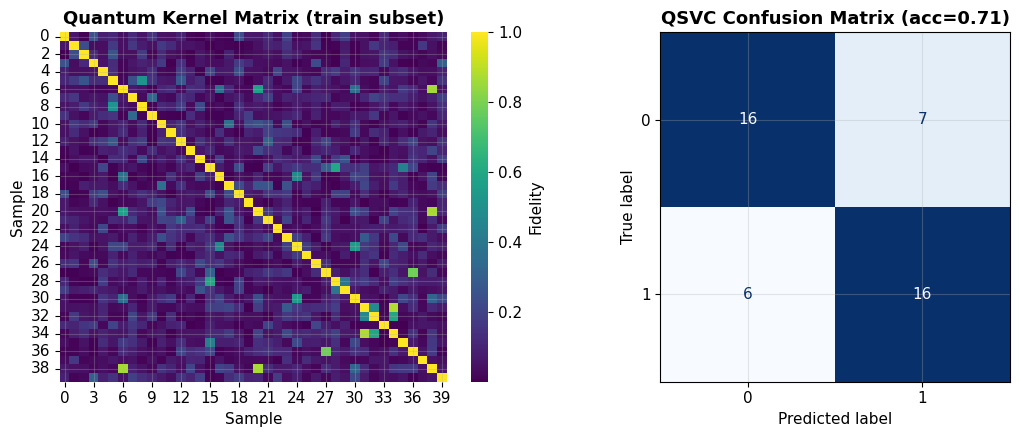

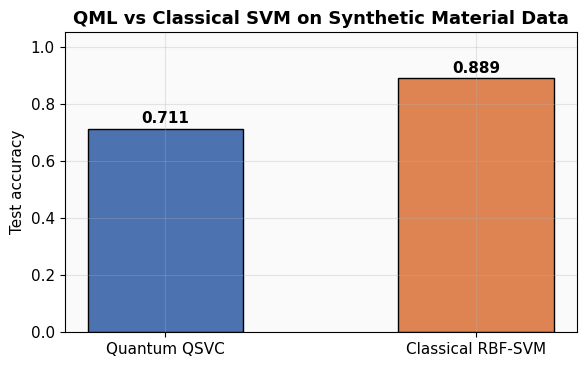

In [ ]:
# Week 3 - Cell 1: QSVC + rich visualizations

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

X, y = make_classification(n_samples=150, n_features=4, n_informative=3,
                           n_redundant=1, n_classes=2, class_sep=1.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

feature_map = ZZFeatureMap(feature_dimension=4, reps=2, entanglement="full")
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# Draw feature map
safe_circuit_draw(feature_map.decompose(), title="ZZFeatureMap (Angle-style encoding + entanglement)", fold=50)

# Train QSVC
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train_sc, y_train)
y_pred = qsvc.predict(X_test_sc)
acc = accuracy_score(y_test, y_pred)

print("=" * 60)
print(f"QSVC test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, digits=3))

svc_classical = SVC(kernel="rbf")
svc_classical.fit(X_train_sc, y_train)
acc_c = svc_classical.score(X_test_sc, y_test)
print(f"Classical RBF-SVM accuracy: {acc_c:.4f}")

# Kernel matrix heatmap (subset for speed)
K = quantum_kernel.evaluate(x_vec=X_train_sc[:40])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(K, ax=axes[0], cmap="viridis", cbar_kws={"label": "Fidelity"})
axes[0].set_title("Quantum Kernel Matrix (train subset)", fontweight="bold")
axes[0].set_xlabel("Sample"); axes[0].set_ylabel("Sample")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], colorbar=False,
                                        cmap="Blues")
axes[1].set_title(f"QSVC Confusion Matrix (acc={acc:.2f})", fontweight="bold")
plt.tight_layout()
plt.show()

# Accuracy comparison
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.bar(["Quantum QSVC", "Classical RBF-SVM"], [acc, acc_c],
       color=["#4C72B0", "#DD8452"], edgecolor="k", width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("QML vs Classical SVM on Synthetic Material Data", fontweight="bold")
for i, v in enumerate([acc, acc_c]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


### 3.2 PennyLane Quantum Neural Network – Architecture & Training Curves


/tmp/ipykernel_493/3288972965.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


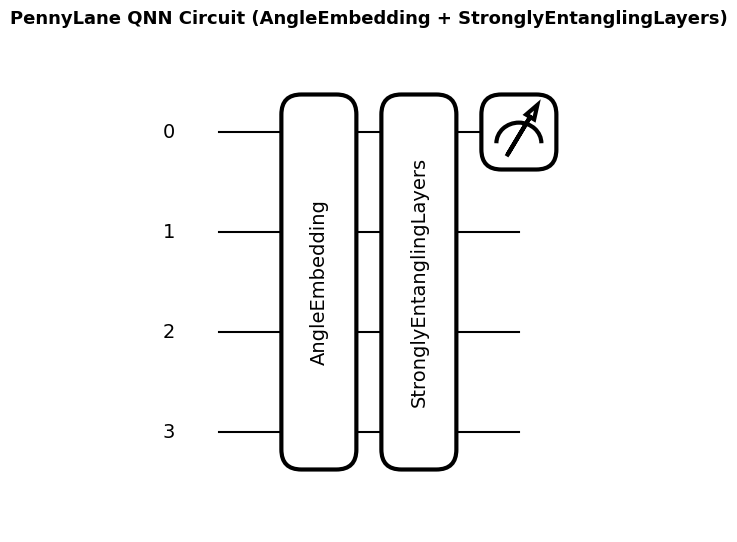

Training PennyLane QNN...
  Epoch  10 | Train MSE: 0.04914
  Epoch  20 | Train MSE: 0.02788
  Epoch  30 | Train MSE: 0.01644
  Epoch  40 | Train MSE: 0.01494
Test MSE: 0.02494


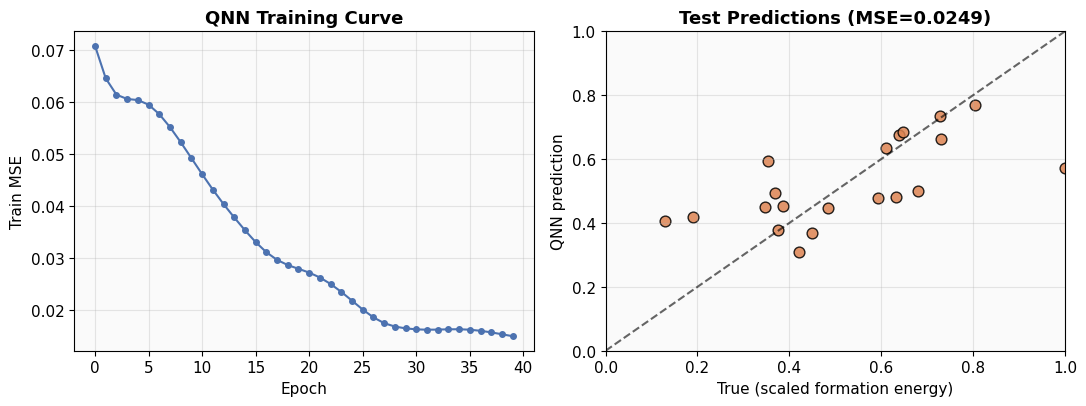

In [ ]:
# Week 3 - Cell 2: QNN regression with training curve

import pennylane as qml
from pennylane import numpy as pnp

n_qubits, n_layers = 4, 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="autograd")
def qnn(inputs, weights):
    # Angle embedding + strongly entangling layers
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

# Draw the QNN circuit once
rng = np.random.default_rng(42)
weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
w_demo = rng.normal(0, 0.1, weight_shape)
x_demo = rng.uniform(0, np.pi, n_qubits)

fig, ax = qml.draw_mpl(qnn, decimals=2)(x_demo, w_demo)
ax.set_title("PennyLane QNN Circuit (AngleEmbedding + StronglyEntanglingLayers)", fontweight="bold")
plt.tight_layout()
plt.show()

# Synthetic formation-energy style target
X_reg = rng.uniform(0, np.pi, size=(80, n_qubits))
y_reg = (0.4*np.sin(X_reg[:,0]) - 0.3*np.cos(X_reg[:,1])
         + 0.2*X_reg[:,2] + 0.1*np.sin(X_reg[:,3]*2))
y_reg = (y_reg - y_reg.min()) / (y_reg.max() - y_reg.min())

split = 60
X_train_qnn, X_test_qnn = X_reg[:split], X_reg[split:]
y_train_qnn, y_test_qnn = y_reg[:split], y_reg[split:]

weights = pnp.array(rng.normal(0, 0.1, weight_shape), requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.08)
epochs = 40
history = []

def cost(weights, X, y):
    preds = pnp.array([qnn(x, weights) for x in X])
    preds_scaled = (preds + 1) / 2
    return pnp.mean((preds_scaled - y) ** 2)

print("Training PennyLane QNN...")
for epoch in range(epochs):
    weights, cost_val = opt.step_and_cost(lambda w: cost(w, X_train_qnn, y_train_qnn), weights)
    history.append(float(cost_val))
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d} | Train MSE: {float(cost_val):.5f}")

test_preds = pnp.array([qnn(x, weights) for x in X_test_qnn])
test_preds_scaled = (test_preds + 1) / 2
test_mse = float(pnp.mean((test_preds_scaled - y_test_qnn) ** 2))
print(f"Test MSE: {test_mse:.5f}")

# Training curve + prediction scatter
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(history, "o-", color="#4C72B0", markersize=4)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train MSE")
axes[0].set_title("QNN Training Curve", fontweight="bold")

axes[1].scatter(y_test_qnn, test_preds_scaled, c="#DD8452", edgecolors="k", s=60, alpha=0.85)
lims = [0, 1]
axes[1].plot(lims, lims, "k--", alpha=0.6)
axes[1].set_xlabel("True (scaled formation energy)")
axes[1].set_ylabel("QNN prediction")
axes[1].set_title(f"Test Predictions (MSE={test_mse:.4f})", fontweight="bold")
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
plt.tight_layout()
plt.show()


### 3.3 Gate-model vs Annealing (D-Wave) Perspective

- **Superconducting gate architectures (Condor / Wukong)** are the natural home for quantum kernels, variational circuits and QNNs.
- **D-Wave quantum annealing** maps the same tasks onto QUBO problems that fit Chimera / Pegasus / Zephyr topologies.

The diagrams above show the gate-model path. In the accompanying GitHub repository a QUBO conversion stub for the same classification task is provided for D-Wave Leap users.


---
# Week 4: Quantum Dynamics, Error Mitigation & Patent Strategy

### Theoretical Content
- Quantum time evolution and Trotterization
- Algorithmic error scaling
- Zero-Noise Extrapolation (ZNE) and Probabilistic Error Cancellation (PEC)
- Intellectual-property architectures for quantum-chemical software


### 4.1 Trotterized Time Evolution – Circuit & Conceptual Diagram


Qubits: 2 | Depth after decompose: 32


<Figure size 900x500 with 0 Axes>

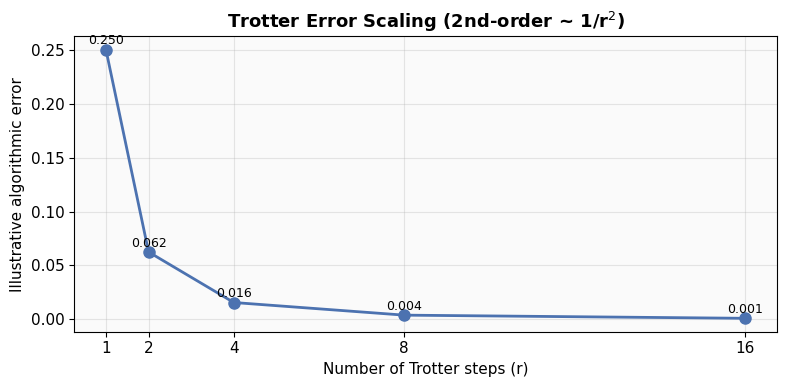

In [ ]:
# Week 4 - Cell 1: Trotter evolution + illustration

from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

H = SparsePauliOp.from_list([
    ("ZZ", 0.40),
    ("XX", 0.25),
    ("YY", 0.15),
    ("ZI", 0.10),   # single-qubit Z on qubit 0 (padded to 2 qubits)
    ("IX", 0.05),   # single-qubit X on qubit 1 (padded to 2 qubits)
])
t, reps = 1.0, 4
synthesis = SuzukiTrotter(order=2, reps=reps)
evo_gate = PauliEvolutionGate(H, time=t, synthesis=synthesis)

qc = QuantumCircuit(H.num_qubits, name="TrotterEvolution")
qc.append(evo_gate, range(H.num_qubits))
decomposed = qc.decompose()

print(f"Qubits: {qc.num_qubits} | Depth after decompose: {decomposed.depth()}")
safe_circuit_draw(decomposed, title="Second-order Suzuki-Trotter Evolution Circuit", fold=60)

# Conceptual Trotter error diagram
fig, ax = plt.subplots(figsize=(8, 4))
steps = np.array([1, 2, 4, 8, 16])
# Illustrative 1/r^2 scaling of Trotter error for 2nd order
error = 0.25 / steps**2
ax.plot(steps, error, "o-", color="#4C72B0", lw=2, markersize=8)
ax.set_xlabel("Number of Trotter steps (r)")
ax.set_ylabel("Illustrative algorithmic error")
ax.set_title("Trotter Error Scaling (2nd-order ~ 1/r$^2$)", fontweight="bold")
ax.set_xticks(steps)
for s, e in zip(steps, error):
    ax.text(s, e + 0.005, f"{e:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


### 4.2 Noise Model & Zero-Noise Extrapolation (ZNE) – Interactive Concept Plot


Noise model constructed:
NoiseModel:
  Basis gates: ['cx', 'cz', 'ecr', 'id', 'rx', 'ry', 'rz', 'sx', 'x']
  Instructions with noise: ['ry', 'sx', 'rz', 'cz', 'ecr', 'rx', 'id', 'cx', 'x']
  All-qubits errors: ['rx', 'ry', 'rz', 'id', 'sx', 'x', 'cx', 'ecr', 'cz']


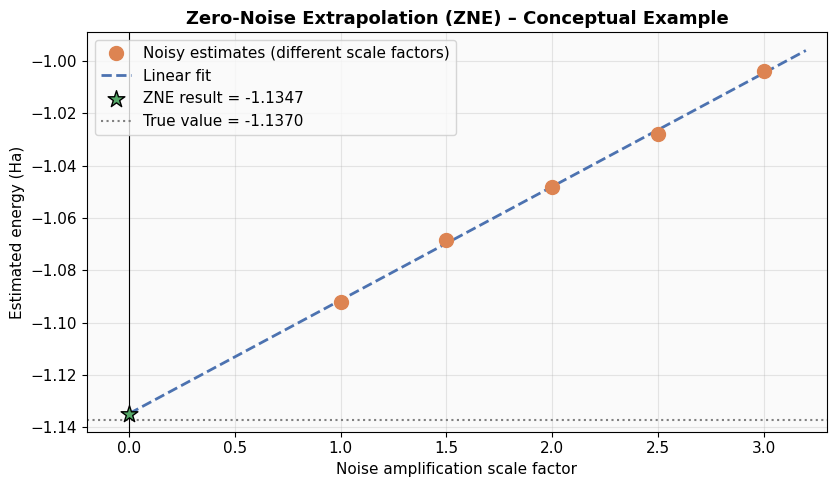

Lab exercise: replace the synthetic points with real noisy VQE runs at several scale factors.


In [ ]:
# Week 4 - Cell 2: Noise model + ZNE conceptual demonstration

from qiskit_aer.noise import NoiseModel, depolarizing_error

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.008, 1),
                                        ['rx', 'ry', 'rz', 'id', 'sx', 'x'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 2),
                                        ['cx', 'ecr', 'cz'])
print("Noise model constructed:")
print(noise_model)

# Conceptual ZNE demonstration (synthetic data)
noise_scales = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
# True noiseless value
true_value = -1.137
# Observed values degrade roughly linearly with scale (toy model)
rng = np.random.default_rng(7)
observed = true_value + 0.045 * noise_scales + rng.normal(0, 0.004, size=noise_scales.shape)

# Linear fit and extrapolation to scale = 0
coef = np.polyfit(noise_scales, observed, 1)
extrapolated = np.polyval(coef, 0.0)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(noise_scales, observed, "o", markersize=10, color="#DD8452",
        label="Noisy estimates (different scale factors)", zorder=5)
x_line = np.linspace(0, 3.2, 50)
ax.plot(x_line, np.polyval(coef, x_line), "--", color="#4C72B0", lw=2, label="Linear fit")
ax.scatter([0], [extrapolated], s=160, c="#55A868", marker="*", zorder=6,
           edgecolors="k", label=f"ZNE result = {extrapolated:.4f}")
ax.axhline(true_value, color="gray", ls=":", label=f"True value = {true_value:.4f}")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Noise amplification scale factor")
ax.set_ylabel("Estimated energy (Ha)")
ax.set_title("Zero-Noise Extrapolation (ZNE) – Conceptual Example", fontweight="bold")
ax.legend(loc="upper left")
ax.set_xlim(-0.2, 3.3)
plt.tight_layout()
plt.show()

print("Lab exercise: replace the synthetic points with real noisy VQE runs at several scale factors.")


### 4.3 Intellectual Property & Commercial Pathways (Discussion Module)

**Key topics for the live lecture**

1. **Protectable assets**
   - Novel active-space heuristics
   - Hybrid classical–quantum workflow architectures
   - Domain-specific error mitigation for chemistry operators
   - Multi-paradigm (gate + annealing) software interfaces

2. **International strategy**
   - Priority filing → PCT within 12 months → national phases (US, EP, CN, JP, KR …)
   - Trade-secret protection for certain classical pre-/post-processing components

3. **Open-source vs proprietary**
   - Core libraries (Qiskit Nature, PennyLane, PySCF) are open
   - Competitive edge often lies in curated data, optimized pipelines and chemistry-specific mitigation

4. **Commercial verticals**
   - Battery materials, catalysts, energy storage – high-value application domains for quantum chemistry software


---
# Course Completion & Next Steps

### What you have accomplished
- Built and **visualized** molecular Hamiltonians and active spaces
- Executed and **diagrammed** UCCSD-VQE and qEOM
- Trained quantum kernels and a QNN with **training curves, heatmaps and circuit drawings**
- Explored Trotterized dynamics and **ZNE extrapolation graphics**
- Understood the hardware mapping path to IBM Condor, Origin Wukong and D-Wave
- Reviewed intellectual-property considerations

### Recommended further work
1. Replace synthetic QML targets with real perovskite / battery descriptors
2. Implement a full ZNE loop on the H₂ or LiH VQE observable
3. Transpile a UCCSD circuit to a real IBM backend and compare depth / gate counts
4. Formulate a classification task as QUBO for D-Wave Leap
5. Explore adaptive ansatze for larger active spaces

### Core References
- Peruzzo et al., Nat. Commun. 5, 4213 (2014)
- McClean et al., New J. Phys. 18, 023023 (2016)
- Cao et al., Chem. Rev. 119, 10856 (2019)

---

**Instructor:** Joseph Volkan Ozcan  
**QCCM-601 – Practical Quantum Chemical Simulation on Advanced Global Hardware**
